# Exercises

### Exercise 1
---
Use the sklearn `make_blobs()` function, in the same way that we used in the lesson, to generate a *non linearly separable* dataset with 2 features.  
Fit a linear SVM to the dataset many times, varying the slack hyperparameter $C$, and calculate the model performance in classifying the data.  
What is, approximately, a the best value of the $C$ hyperparameter for this dataset?

        The hyperparameter C in the SVM controls the balance between maximizing the margin and minimizing classification error. As we discussed in the lesson, the more slack you are willing to accept for your model, the bigger the margin, which is a trade-off. From our figure below we can see that the best value of the hyperparameter C is around 1.0 (a bit smaller), as we can see in the plot that the linear SVM reaches the highest cross-validation accuracy. A lower C allows a larger margin, which results in more wrong classifications of the model, resulting in a lower accuracy (as we can also see in the plot). A higher C results in a extremely small margin, which can result in overfitting of data that is actually noise, and the accuracy of the model drops slightly again compared to the optimal hyperplane. This emphasizes again the trade-off between a larger margin and minimizing the classification error.

In [14]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [2]:
#donwload lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/NrNbvEOH7SImYLn')

In [ ]:
X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=.8)

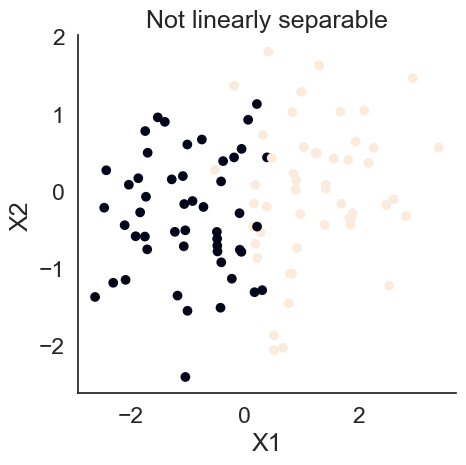

In [5]:
plt.figure(figsize=(5,5))
plt.title('Not linearly separable')
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X_nsep[:,0],X_nsep[:,1],c=y_nsep)

plt.tight_layout()

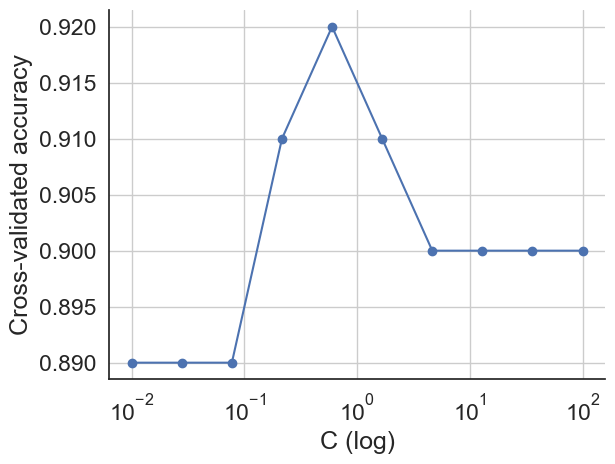

In [ ]:
X, y = X_nsep, y_nsep 

C_values = np.logspace(-2, 2, 10)  #test C values from 0.01 to 100
accuracies = []

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    scores = cross_val_score(clf, X, y, cv=5) 
    accuracies.append(scores.mean())

#plot model performance vs C values
plt.figure()
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C (log)')
plt.ylabel('Cross-validated accuracy')
plt.grid(True)
plt.show()